In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
import seaborn as sns

from my_funs import *
from plot_peak import *

from itertools import product
from sklearn import metrics
from matplotlib import gridspec
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'

dongs = ['강남동', '교  동', '근화동', '남  면', '남산면', '동  면', '동내면', '동산면', '북산면',
       '사북면', '서  면', '석사동', '소양동', '신동면', '신북읍', '신사우동', '약사명동', '조운동',
       '퇴계동', '효자1동', '후평1동']

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [2]:
setting = pd.read_csv('ewma_setting.csv')

idx = setting[setting['funs'] == 'alpha'].index
setting.loc[idx, 'fun'] = moving_average_alpha
idx = setting[setting['funs'] == 'com'].index
setting.loc[idx, 'fun'] = moving_average_com
idx = setting[setting['funs'] == 'span'].index
setting.loc[idx, 'fun'] = moving_average_span
idx = setting[setting['funs'] == 'halflife'].index
setting.loc[idx, 'fun'] = moving_average_halflife


setting

,Unnamed: 0,funs,factor,fun,model_ckpt
0,0,alpha,0.00,<function moving_average_alpha at 0x7ff649271670>,ewma_test/lightning_logs/version_27/checkpoint...
1,1,alpha,0.03,<function moving_average_alpha at 0x7ff649271670>,ewma_test/lightning_logs/version_28/checkpoint...
2,2,alpha,0.06,<function moving_average_alpha at 0x7ff649271670>,ewma_test/lightning_logs/version_29/checkpoint...
3,3,alpha,0.09,<function moving_average_alpha at 0x7ff649271670>,ewma_test/lightning_logs/version_30/checkpoint...
4,4,com,1.00,<function moving_average_com at 0x7ff649247ca0>,ewma_test/lightning_logs/version_31/checkpoint...
5,5,com,6.00,<function moving_average_com at 0x7ff649247ca0>,ewma_test/lightning_logs/version_32/checkpoint...
6,6,com,11.00,<function moving_average_com at 0x7ff649247ca0>,ewma_test/lightning_logs/version_33/checkpoint...
7,7,com,16.00,<function moving_average_com at 0x7ff649247ca0>,ewma_test/lightning_logs/version_34/checkpoint...
8,8,span,1.00,<function moving_average_span at 0x7ff6491e5a60>,ewma_test/lightning_logs/version_35/checkpoint...
9,9,span,6.00,<function moving_average_span at 0x7ff6491e5a60>,ewma_test/lightning_logs/version_36/checkpoint...


# all trial plot

0 prediction is zero
강남동 peak max : 1.392157 // peak_meam 0.299044 , threshlod 0.845600
강남동 peak max : 0.968381 // peak_meam 0.193105 , threshlod 0.580743
강남동 peak max : 0.939234 // peak_meam 0.145678 , threshlod 0.542456
4 prediction is zero
5 prediction is zero
강남동 peak max : 0.105949 // peak_meam 0.069180 , threshlod 0.087565
강남동 peak max : 0.721109 // peak_meam 0.106098 , threshlod 0.413603
8 prediction is zero
9 prediction is zero
강남동 peak max : 0.008093 // peak_meam 0.003373 , threshlod 0.005733
강남동 peak max : 0.467073 // peak_meam 0.088150 , threshlod 0.277612
12 prediction is zero
강남동 peak max : 0.715541 // peak_meam 0.089959 , threshlod 0.402750
강남동 peak max : 1.045318 // peak_meam 0.124446 , threshlod 0.584882
강남동 peak max : 0.969096 // peak_meam 0.232642 , threshlod 0.600869


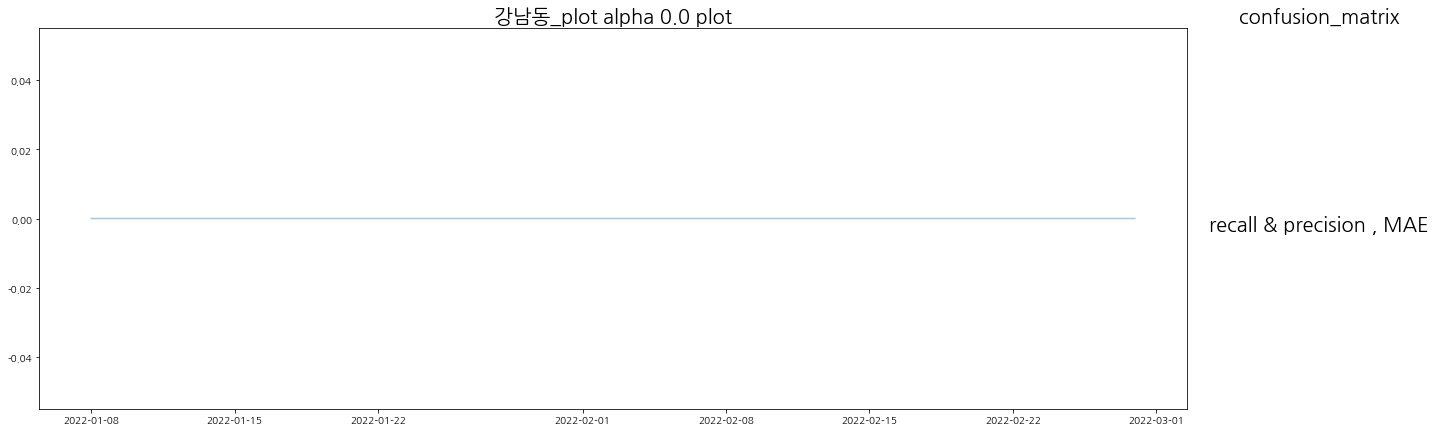

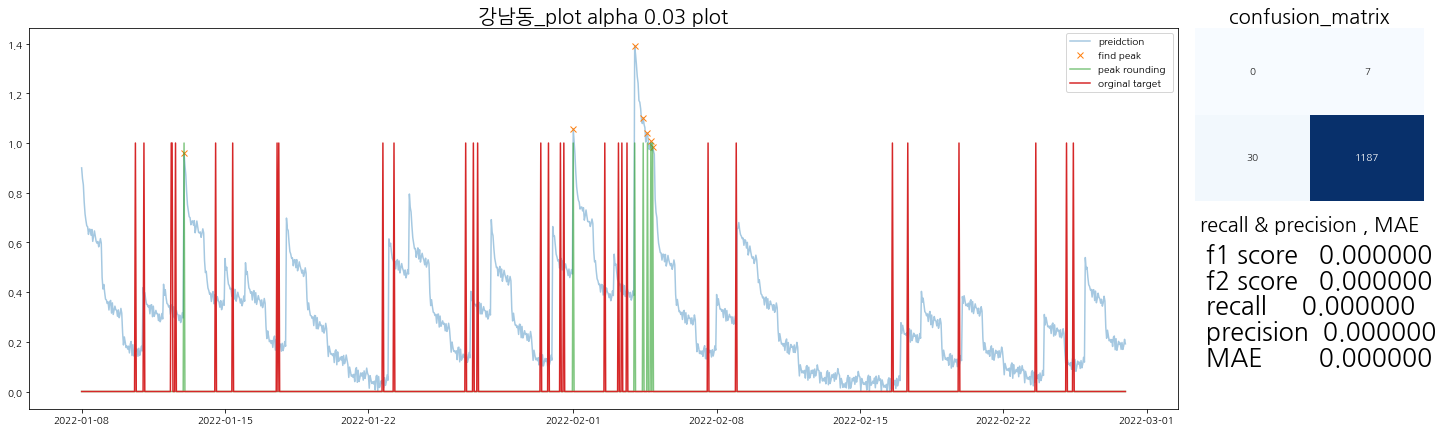

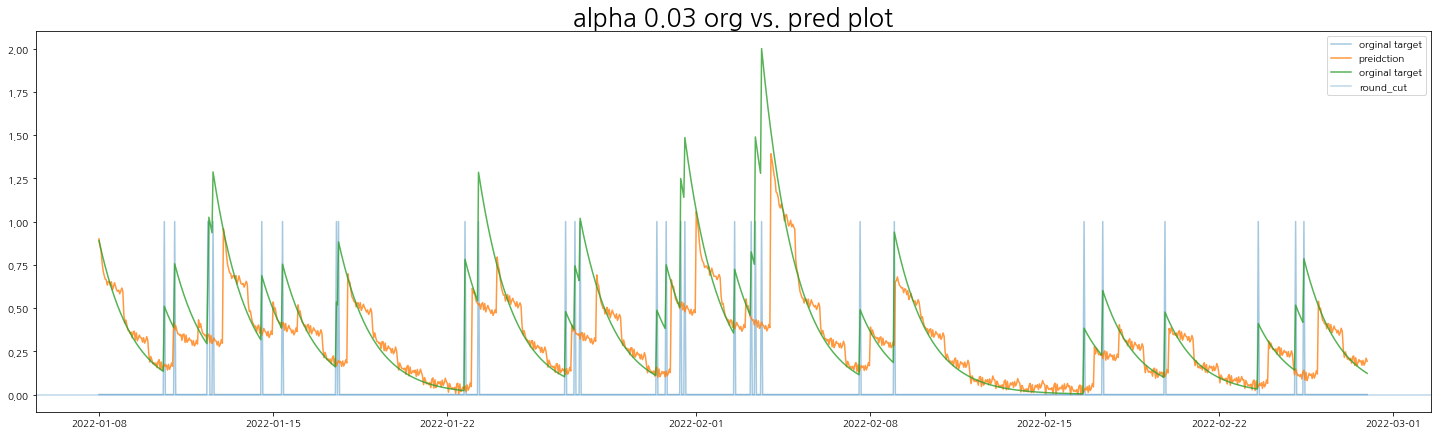

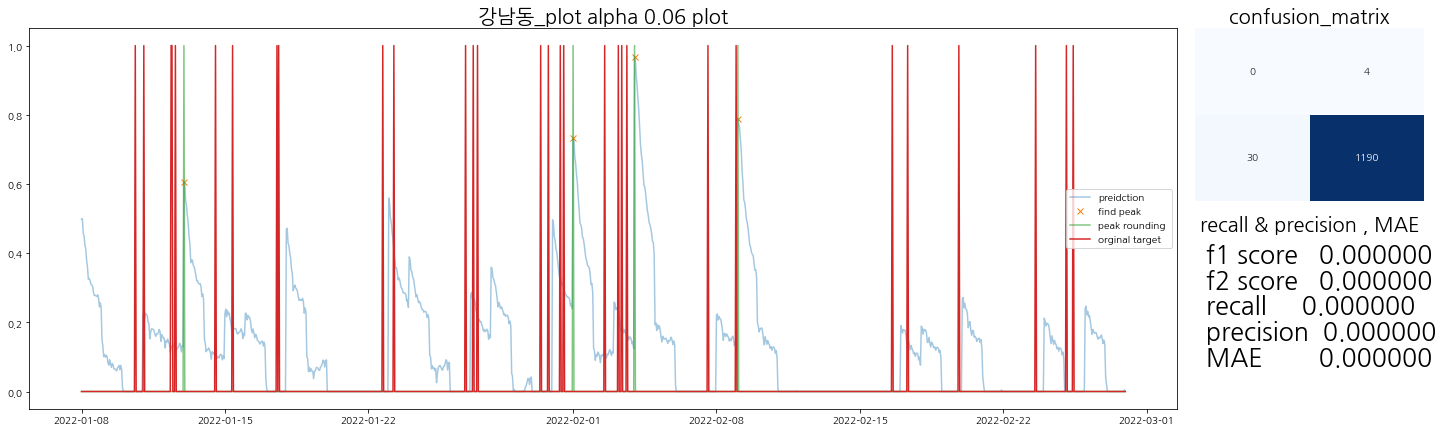

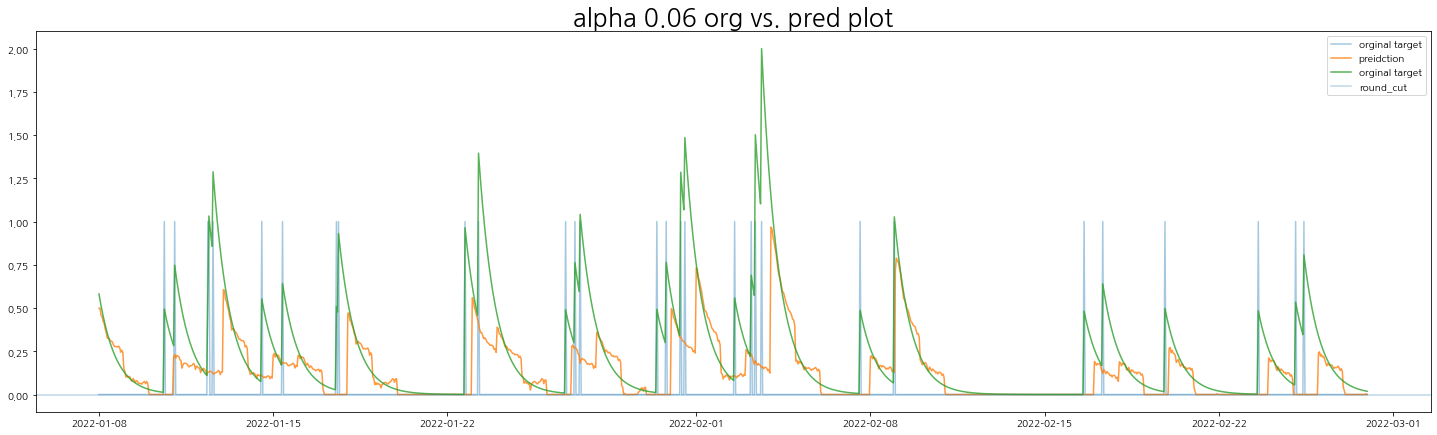

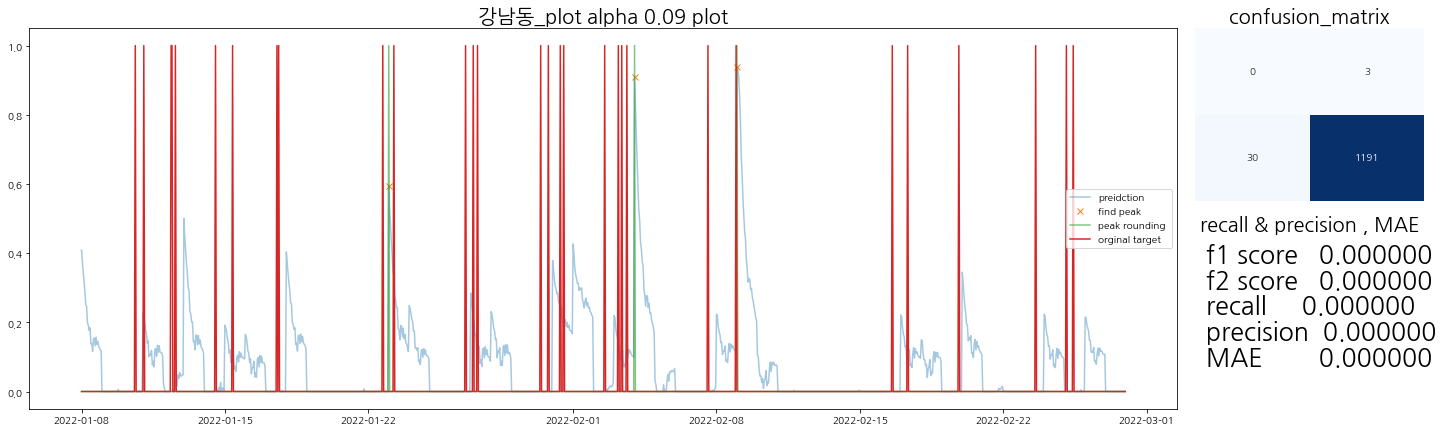

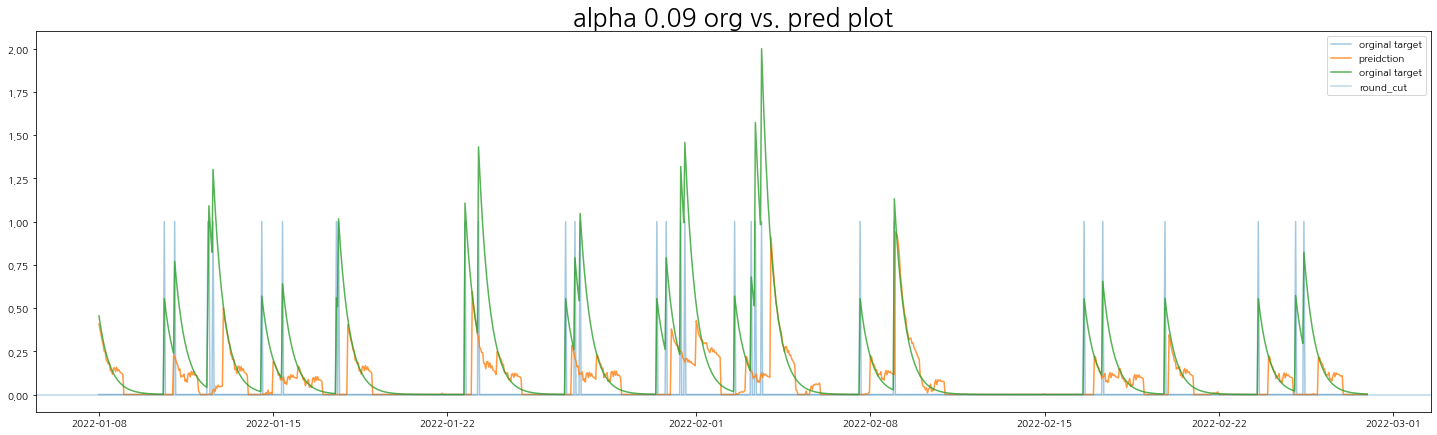

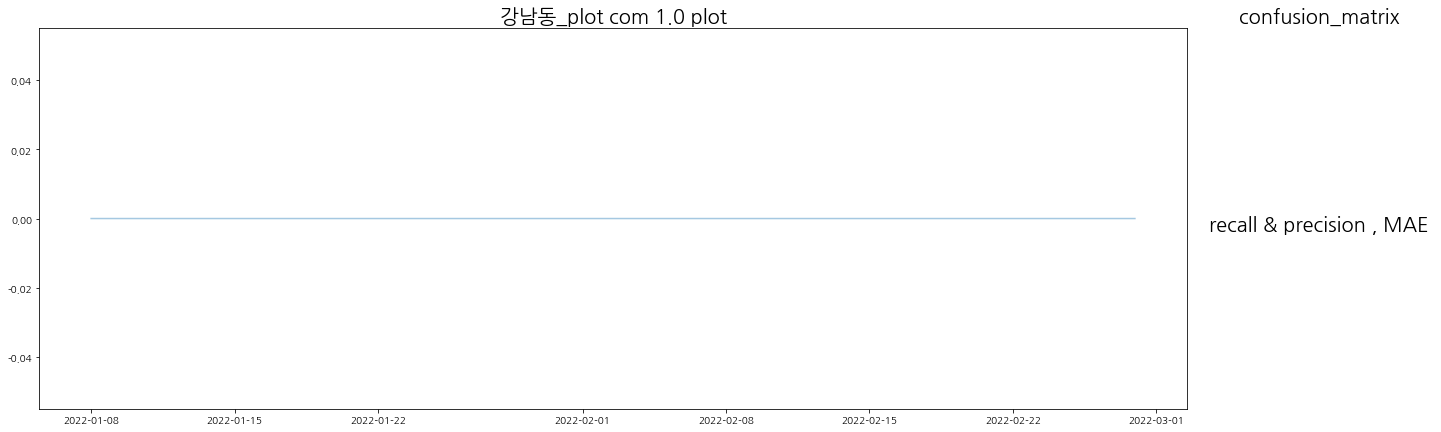

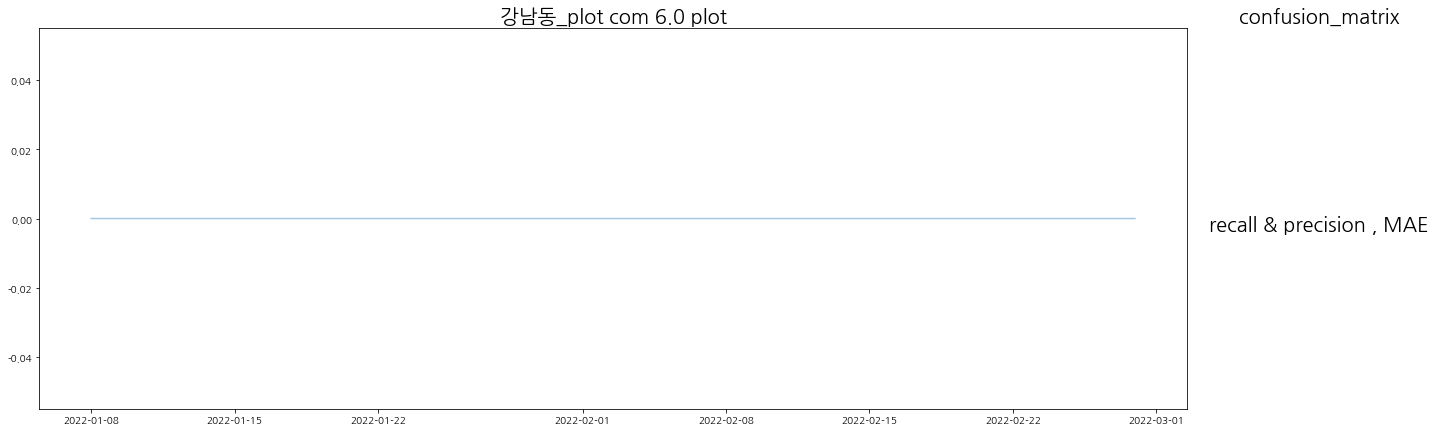

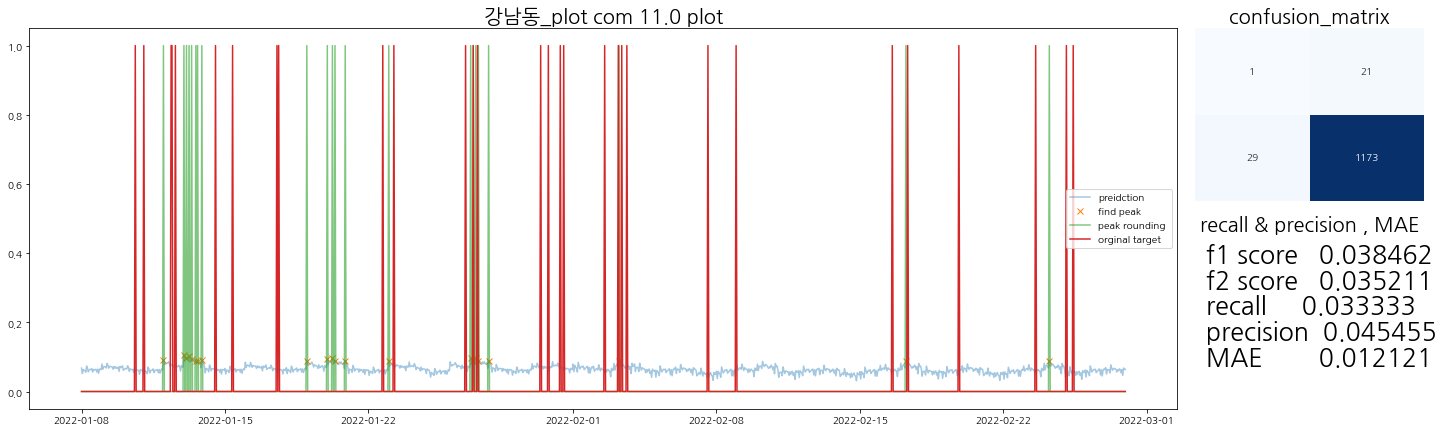

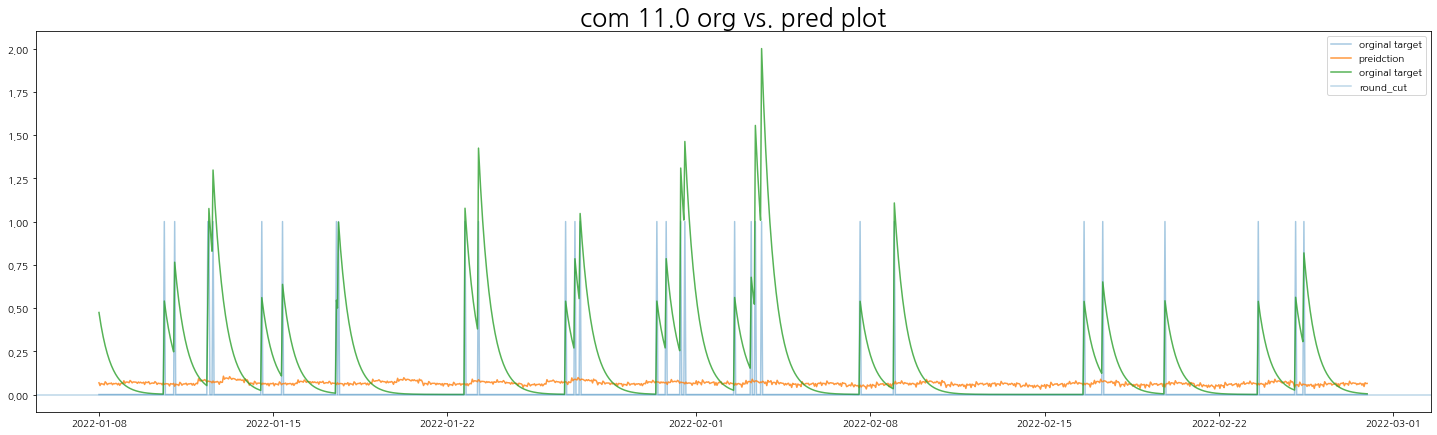

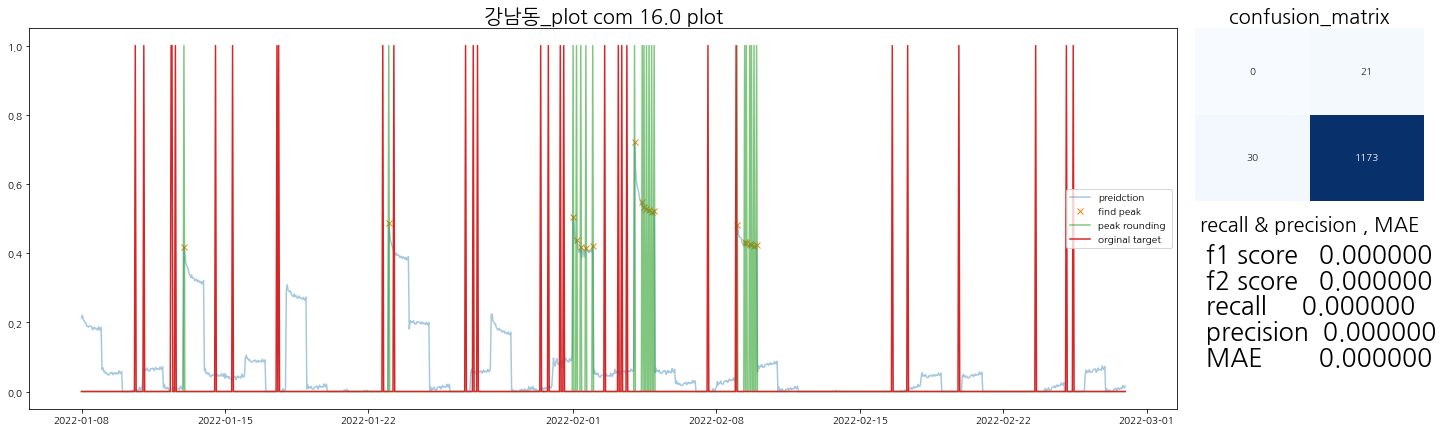

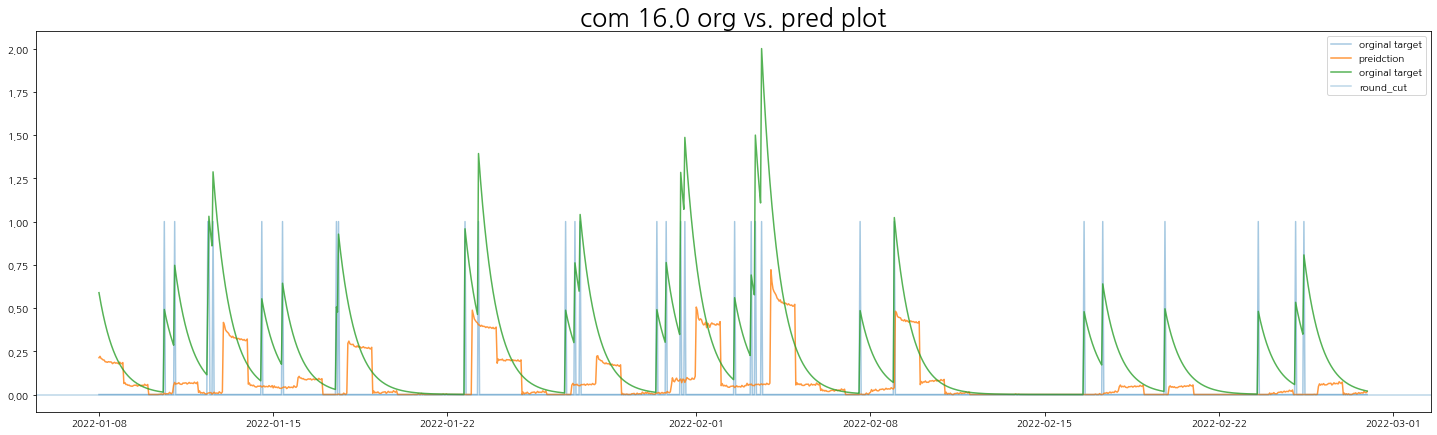

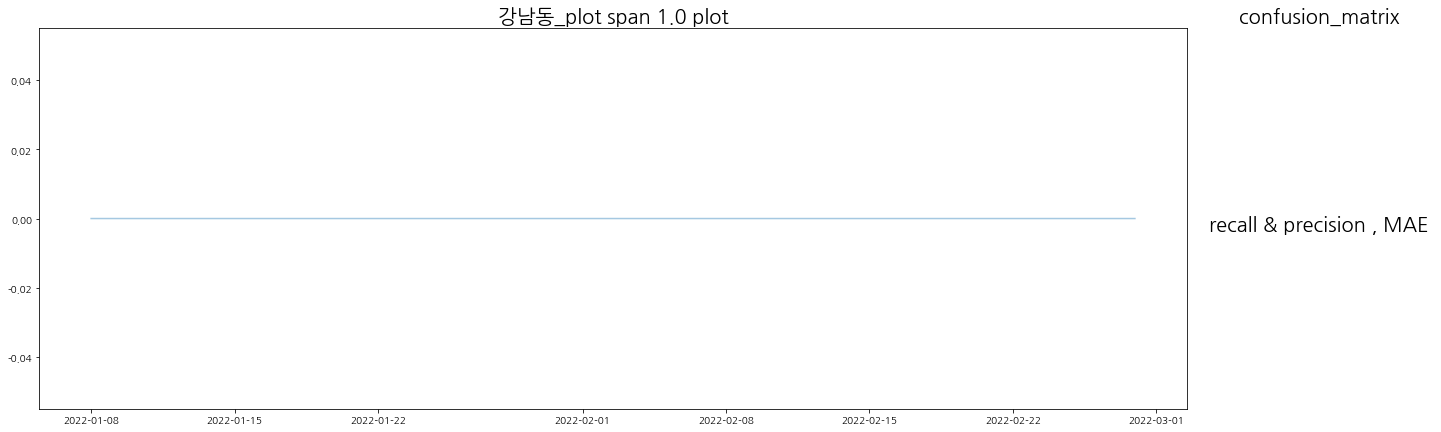

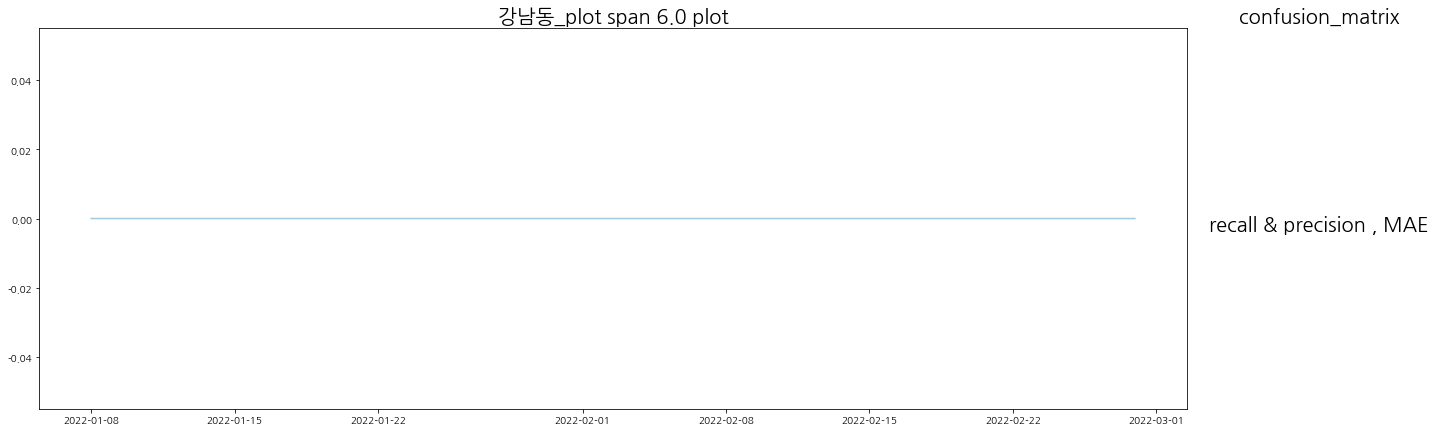

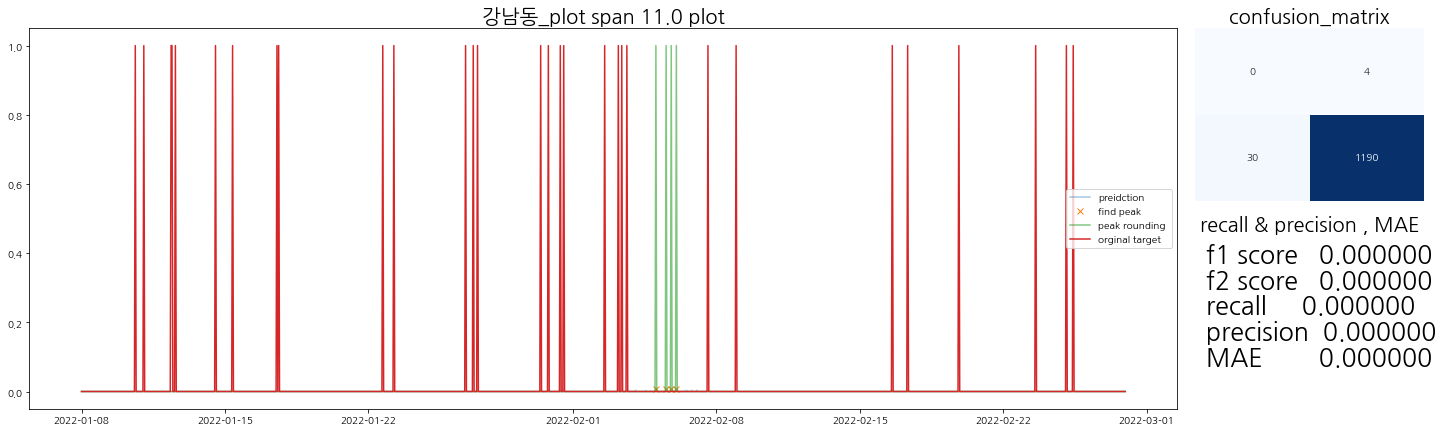

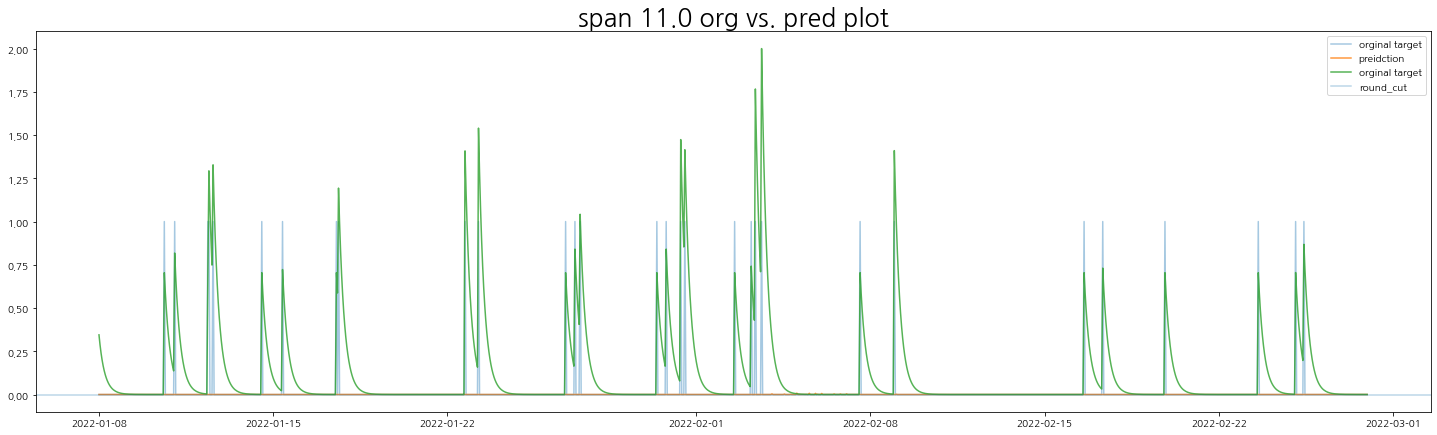

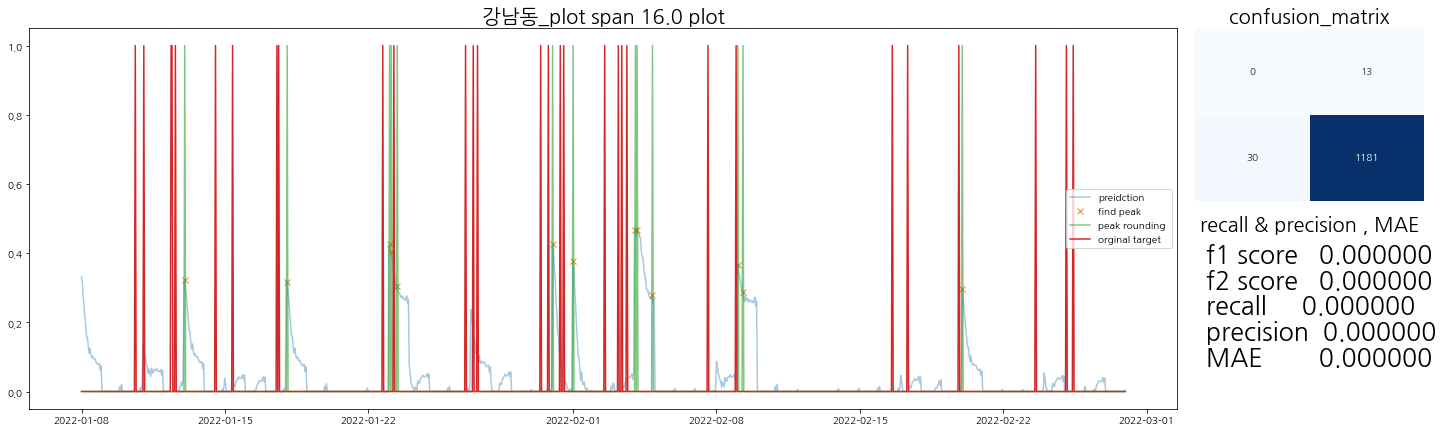

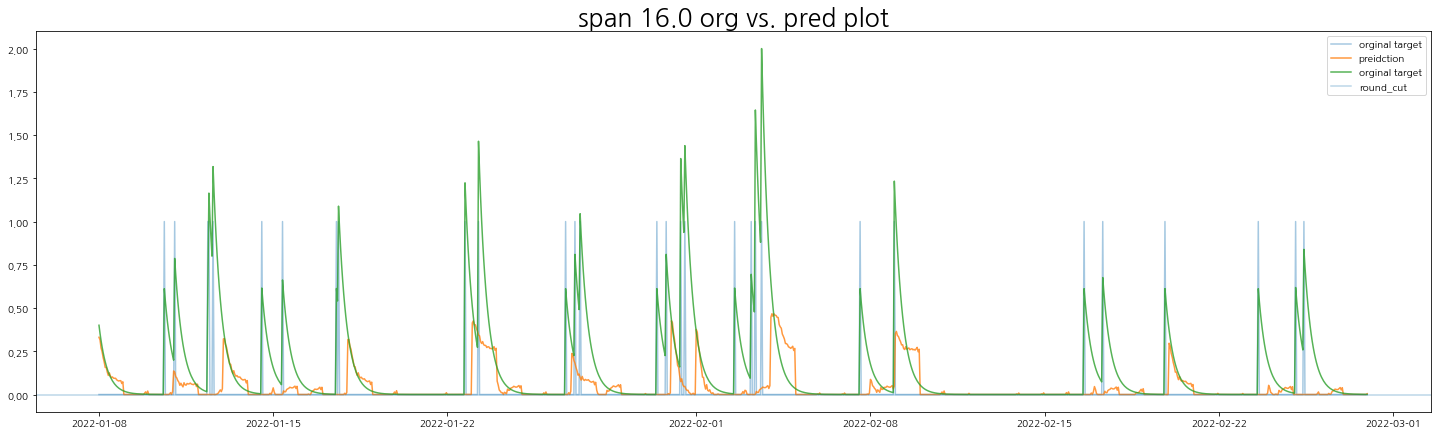

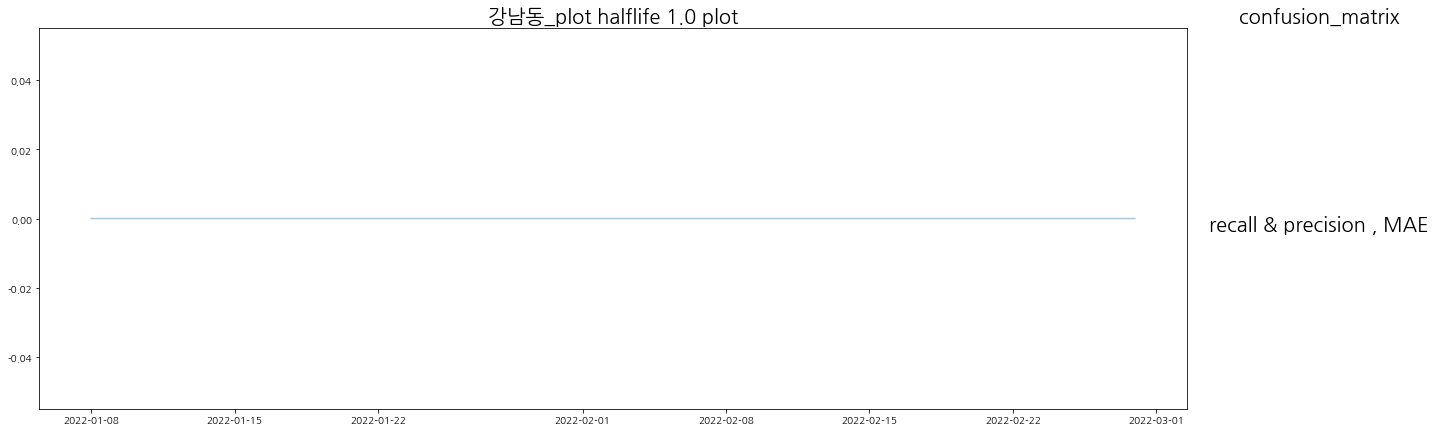

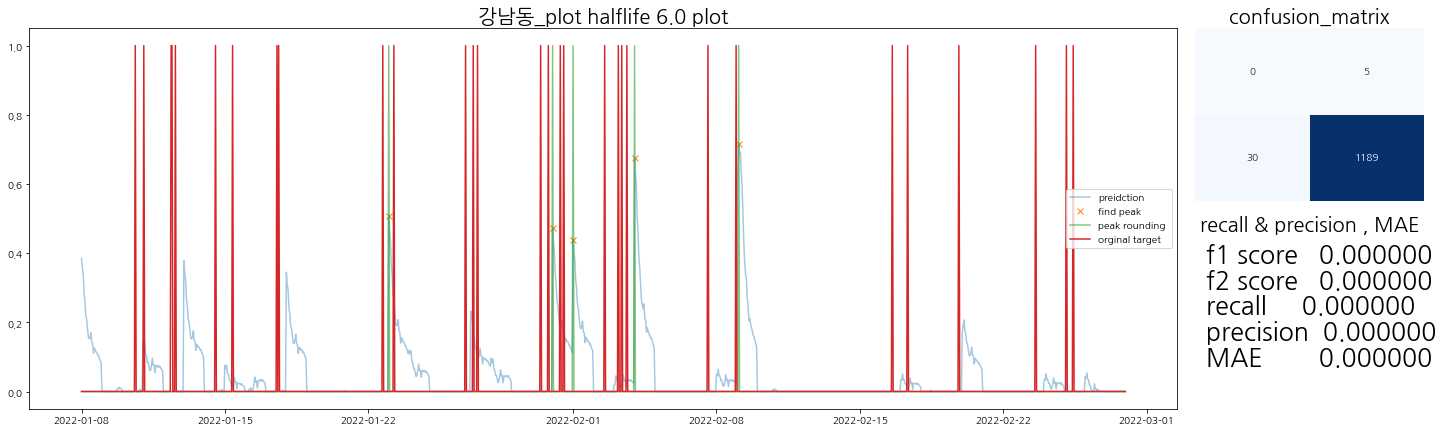

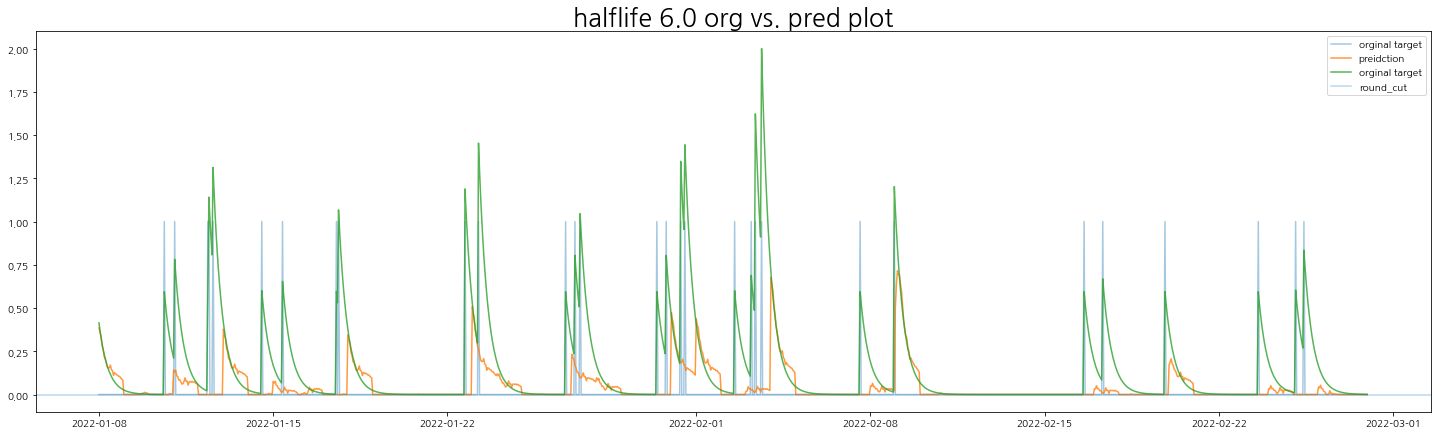

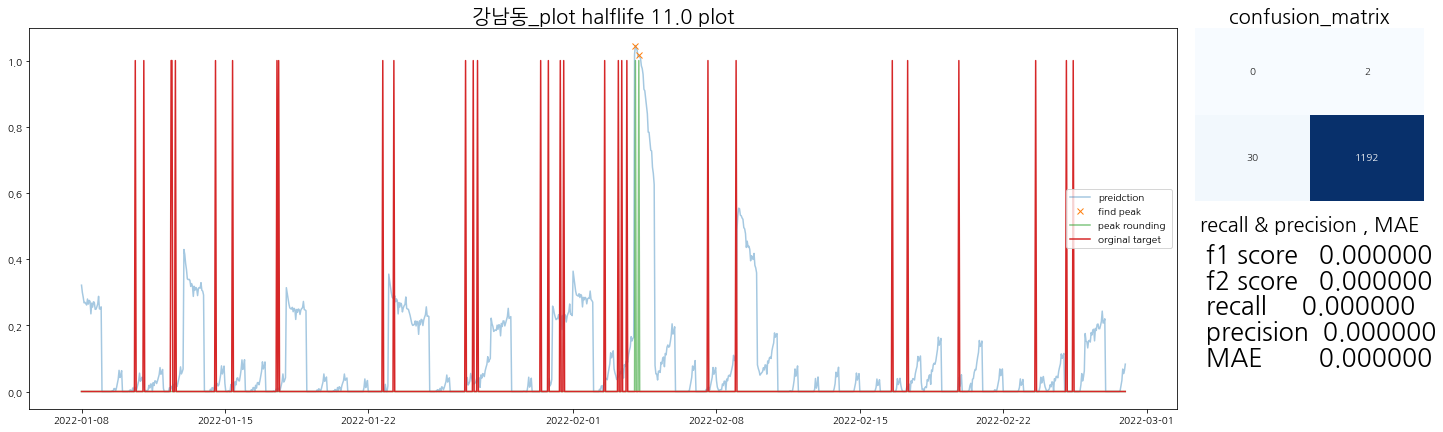

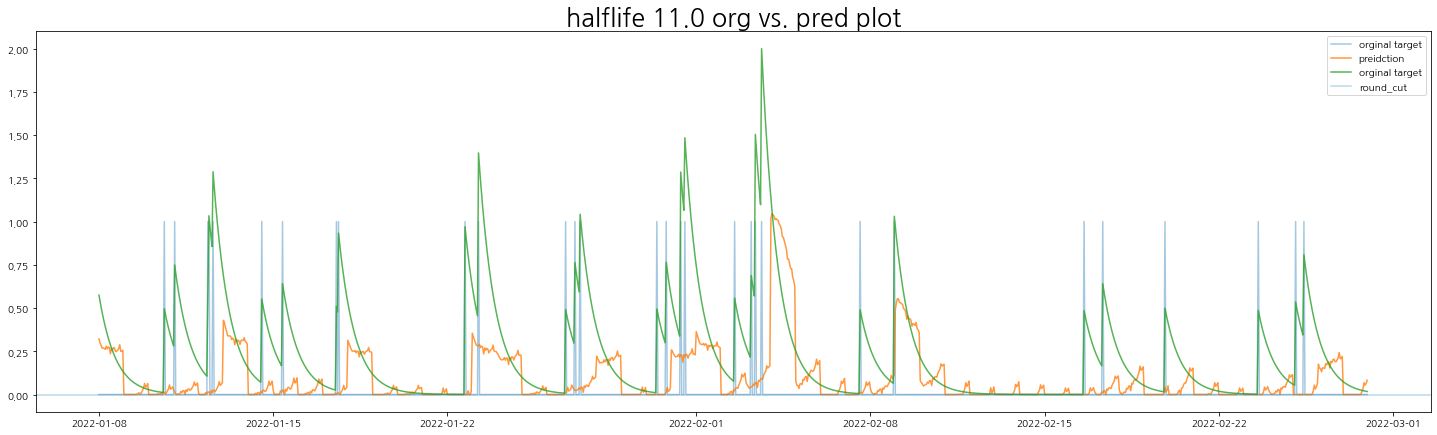

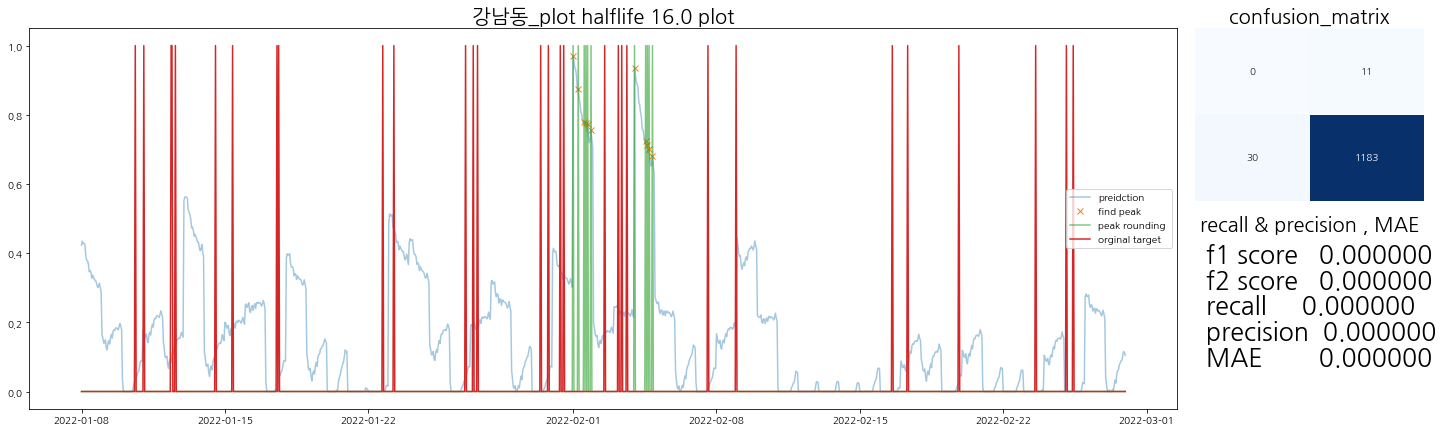

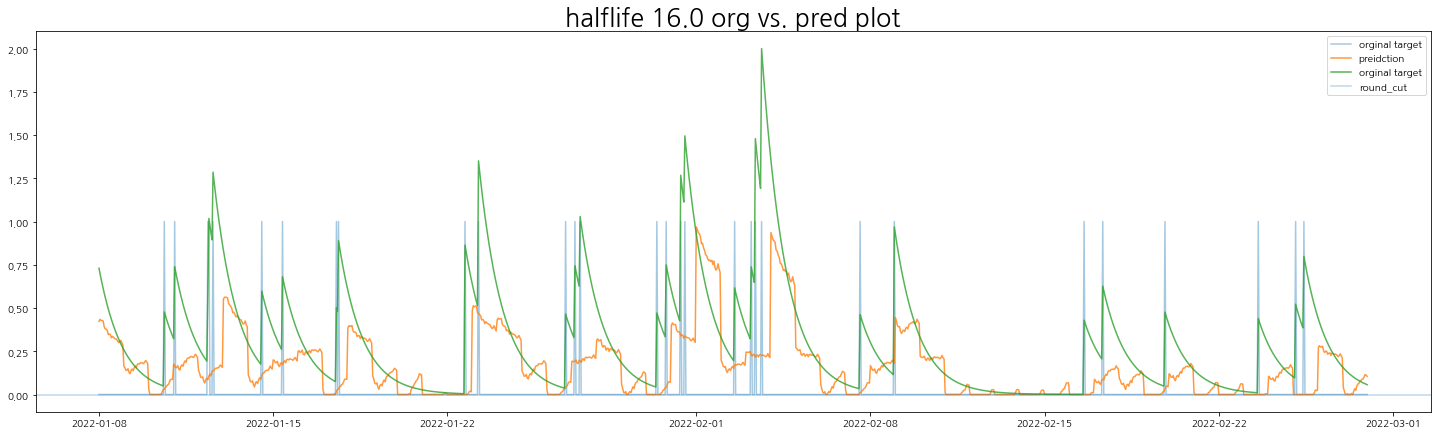

In [3]:
for idx in setting.index:
    model_ckpt = setting['model_ckpt'].loc[idx]
    factor = setting['factor'].loc[idx]
    funs = setting['fun'].loc[idx]
    fun_type = setting['funs'].loc[idx]
    train_data = data_processing('../../train.csv' , factor , funs)
    test_data = data_processing('../../test.csv' , factor, funs)
    training = get_training(train_data , 24, 24*7)
    tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)
    try:
        confusion_matrix_plot_peak_v2(training, tft ,test_data ,'강남동' , f'{fun_type} {factor} plot')
        prediction_plot_n(training, tft ,test_data ,'강남동' , f'{fun_type} {factor} org vs. pred plot',0, 3)
    except:
        print(f'{idx} prediction is zero')